In [ ]:
# Workflow
1.	Raw Input → Embedding (Vectorization)
	•	Text (like "The cat sat on the mat") is converted into a numerical vector embedding.
	•	These embeddings capture semantic meaning.
	•	Example: "cat" → [0.21, -0.34, 0.87, ...].
2.	Autoencoder (or Transformer Encoder) → Latent Representation 
	•	The embeddings are fed into an encoder (e.g., BERT encoder, transformer block, or classical autoencoder).
	•	The encoder compresses and transforms them into a latent representation.
            - Latent representation captures context + meaning.
            - For example:
                	•	In context ("The cat sat on the mat"), it becomes:
                        [0.45, 0.77, -0.21, ...] → encodes the idea “cat as subject sitting on something”.
                
	•	This step helps the model learn contextual relationships and a richer representation.
3.	Decoder (if present)
	•	The decoder tries to reconstruct missing text (masked tokens in BERT) or generate new text (GPT-style).
	•	During this, the latent representation (from step 2) is refined into something meaningful.

# Chunks
    • Convert our chunks of text into Vectors using OpenAlEmbeddings
    • Store the Vectors in Chroma, one of the most popular open-source Vector datastores
    • Visualize and explore Vectors in a Chroma Vector Datastore in 2D and 3D            

In [ ]:
# Workflow

[ User Query ]
   e.g. "What services does our company provide in AI consulting?"
        |
        v
+-------------------+
| Query Preprocessing|
+-------------------+
  - Clean text, normalize, optional stopword removal
        |
        v
+---------------------------------------------+
| Query Embedding (OpenAI text-embedding-3)   |
+---------------------------------------------+
  - Converts query into high-dimensional vector
  - Example: [0.12, -0.33, 0.91, ...]
        |
        v
+---------------------------------------------+
| Vector Database (Chroma)                     |
+---------------------------------------------+
  - Stores company knowledge base as vectors
  - Metadata: document IDs, titles, chunks
  - Performs Similarity Search (kNN lookup)
  - Returns top-k most relevant documents
        |
        v
+-----------------------------+
| Retrieved Context (Top Docs)|
+-----------------------------+
  e.g. "Our company provides AI consulting,
       cloud migration, and data engineering."
        |
        v
+---------------------------------------------+
| Context Assembly (Prompt Engineering)        |
+---------------------------------------------+
  - Combines:
      • User query
      • Retrieved context
      • Instructions / system prompt
  - Example final prompt:
    "Answer the user using the company data:
     Context: [doc1: AI consulting ...]
     Question: What services does our company provide?"
        |
        v
+---------------------------------------------+
| LLM (OpenAI GPT / other model)              |
+---------------------------------------------+
  - Consumes the prompt
  - Uses reasoning + retrieved context
  - Generates a natural language response
        |
        v
+------------------+
| Post-processing  |
+------------------+
  - Optional: summarization, formatting, safety filters
        |
        v
[ Final Answer to User ]
   "Our company provides AI consulting,
    cloud migration, and data engineering."


# Explaination
1. Query Embedding (OpenAI text-embedding-3)
	•	It is a pre-trained generic embedding model from OpenAI.
	•	It’s not trained on your company data — it’s trained on a massive public corpus.
	•	Its job is only to take text (your query) and output a vector (decimal array) that captures semantic meaning.
	•	Example:
            What services do you provide? → [0.12, -0.45, 0.88, ...].

2. Chroma (Vector Database)
	•	This is where your company knowledge base lives.
	•	Steps to prepare it (offline ingestion):
	•	Take company docs (FAQs, PDFs, manuals, emails).
	•	Break them into smaller chunks (paragraphs/sentences).
	•	Use the same OpenAI embedding model to convert each chunk → vector.
	•	Store vectors + metadata (title, source, chunk text) in Chroma.
	•	At query time:
    	•	Chroma compares the query embedding with stored embeddings.
    	•	Finds the most similar chunks (nearest neighbors).
    	•	Returns those as retrieved context for the LLM.        

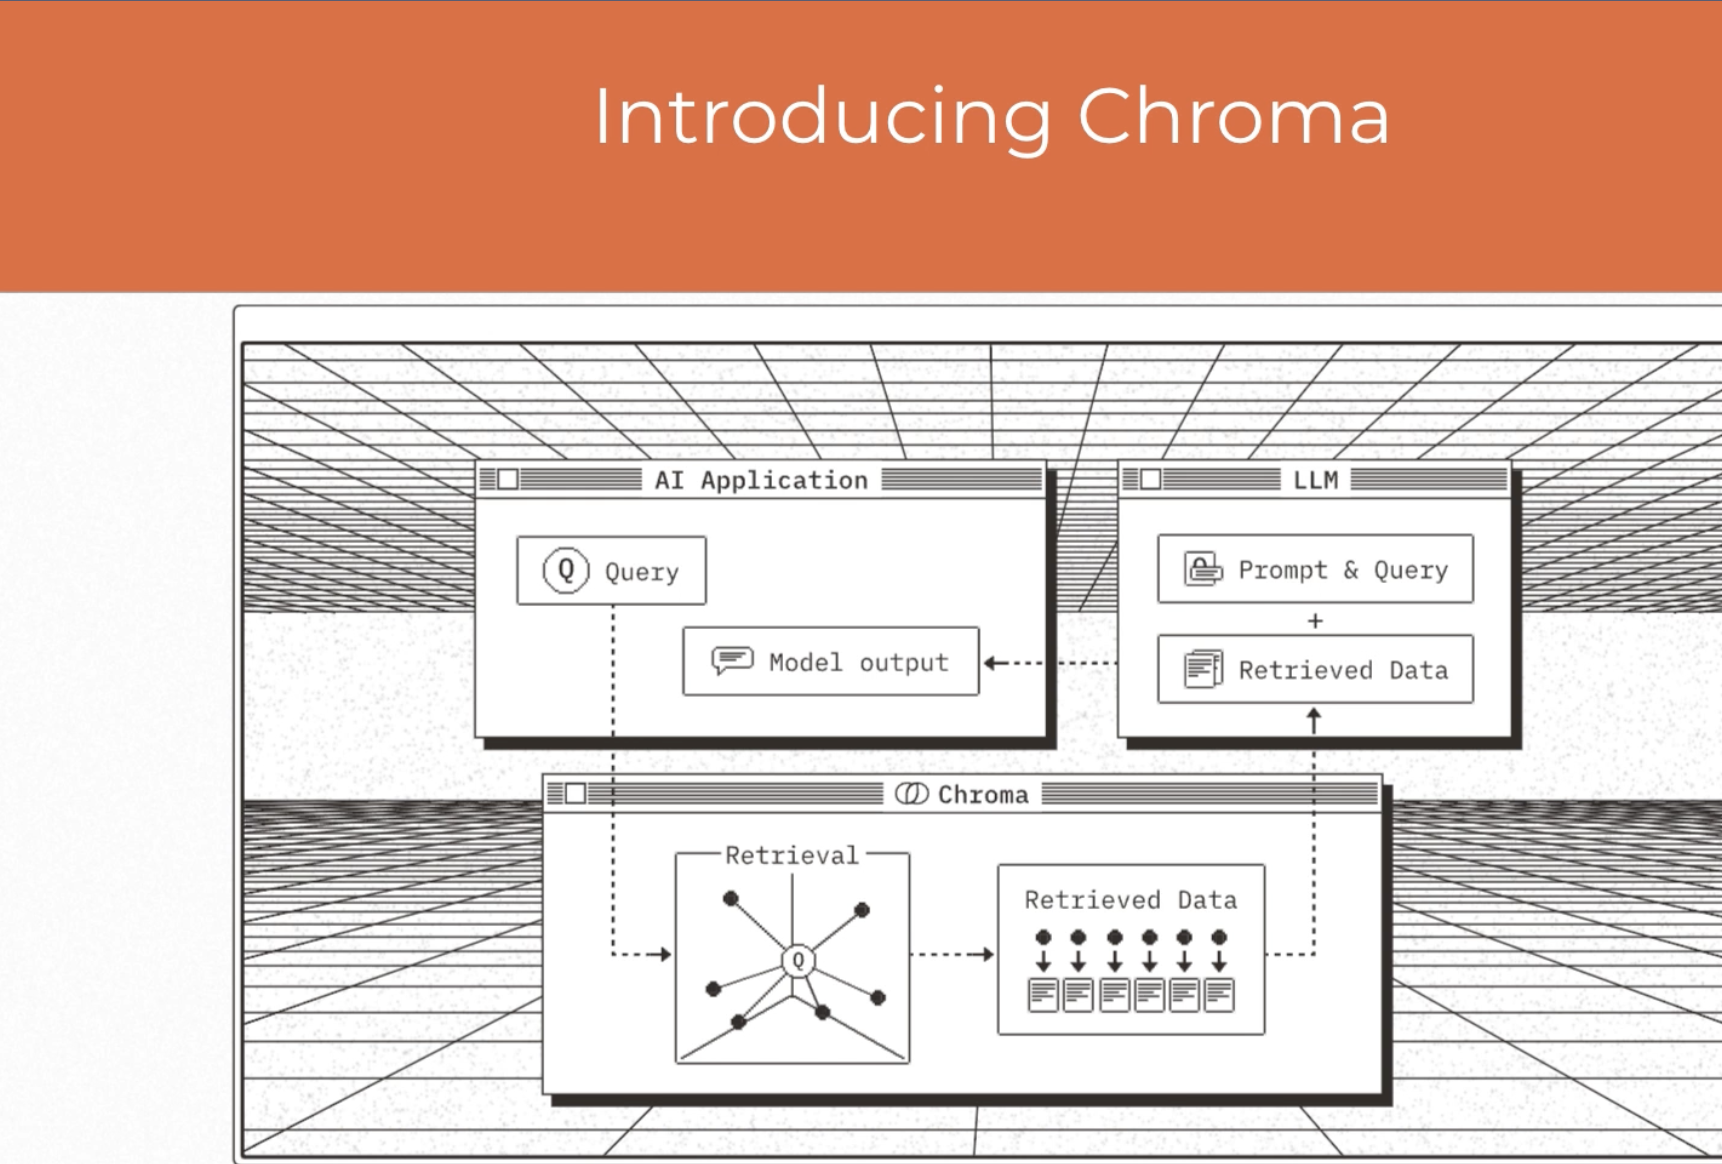

In [ ]:
882338608
Harekrishna@123